Génération de l'Univers de test (104 matchs)...
Lancement du DP de Calibration (Calcul de l'Espérance Baseline)...
Cible à atteindre au Match 1 : 8.33%

Lancement de la recherche du k optimal par minimisation de la MSE...

k = 5.20 | MSE = 0.2320 | Match 1 (DP): 7.23% (Cible: 8.33%)
k = 5.26 | MSE = 0.2041 | Match 1 (DP): 7.32% (Cible: 8.33%)
k = 5.32 | MSE = 0.1830 | Match 1 (DP): 7.42% (Cible: 8.33%)
k = 5.38 | MSE = 0.1682 | Match 1 (DP): 7.52% (Cible: 8.33%)
k = 5.44 | MSE = 0.1594 | Match 1 (DP): 7.62% (Cible: 8.33%)
k = 5.50 | MSE = 0.1561 | Match 1 (DP): 7.71% (Cible: 8.33%)
k = 5.56 | MSE = 0.1579 | Match 1 (DP): 7.81% (Cible: 8.33%)
k = 5.62 | MSE = 0.1646 | Match 1 (DP): 7.90% (Cible: 8.33%)
k = 5.68 | MSE = 0.1757 | Match 1 (DP): 8.00% (Cible: 8.33%)
k = 5.74 | MSE = 0.1910 | Match 1 (DP): 8.09% (Cible: 8.33%)
k = 5.80 | MSE = 0.2101 | Match 1 (DP): 8.18% (Cible: 8.33%)

🏆 LE MEILLEUR PARAMÈTRE EST k = 5.50 avec une MSE minimale de 0.1561


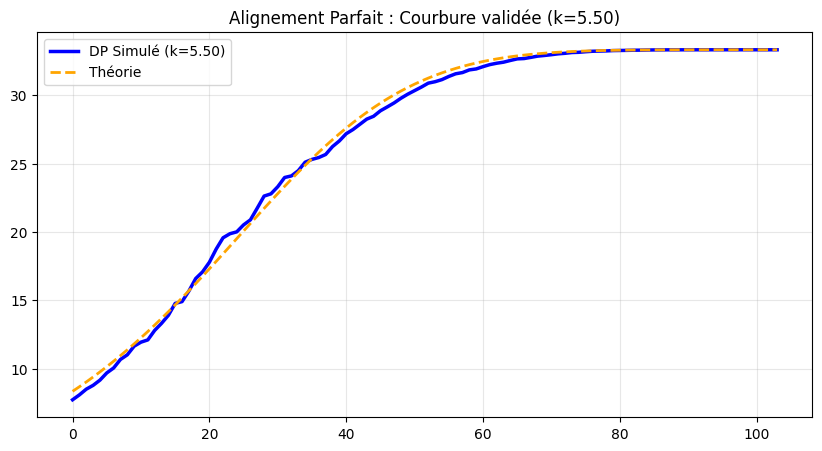

In [4]:
# ==============================================================================
# CALIBRATION DU SUPER-ADVERSAIRE : TEST D'ÉQUITÉ DE LA BASELINE (1/N_PLAYERS)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import sys
from pathlib import Path

# --- IMPORTS DU PROJET ---
notebook_dir = Path.cwd()
project_root = notebook_dir.parent 
sys.path.append(str(project_root))

from mpp_project.mpp_env import MppEnv
from mpp_project.core import estimate_crowd_3D

# --- 1. PARAMÈTRES DU TEST ---
N_PLAYERS = 12
N_MATCHES = 104
GRID_SIZE = 1001
GAP_OFFSET = 600

match_params = {
    'n_matches': N_MATCHES,
    'ev_avg': 35,
    'draw_fact_min': 0.2,
    'draw_fact_max': 0.75,
    'outsider_fact_min': 1/7.5,
    'outsider_fact_max': 1.0,
    'proba_fact_std': 0.06 
}

# --- 2. GÉNÉRATION D'UN TOURNOI COMPLET (Via MppEnv) ---
print("Génération de l'Univers de test (104 matchs)...")
env = MppEnv(
    n_players=N_PLAYERS, 
    n_matches=N_MATCHES, 
    match_params=match_params,
    num_random_opponents=N_PLAYERS - 1,
    use_domain_randomization=False,
    use_winner_reward=False
)
env.reset()
env._generate_tournament()

true_probas = env.outcome_probas 
mpp_gains = env.match_gains

# Génération de la Foule (Crowd)
c1, cN, c2 = estimate_crowd_3D(true_probas[:, 0], true_probas[:, 1], true_probas[:, 2])
crowds = np.column_stack((c1, cN, c2))

# --- 3. LE MOTEUR Numba DE CALIBRATION (L'Agent joue comme la Foule) ---
@njit
def solve_calibration_dp(probas, gains, crowds, n_players, n_matches, k):
    """
    Rétro-propagation où l'Agent ne fait PAS de Argmax. 
    Il tire son choix proportionnellement à la foule (Agent Lambda).
    """
    V_next = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)
    
    # Condition de victoire à la fin du tournoi
    for g1 in range(GRID_SIZE):
        val_g1 = g1 - GAP_OFFSET
        for g2 in range(GRID_SIZE):
            val_g2 = g2 - GAP_OFFSET
            
            if val_g1 > 0 and val_g2 > 0:
                V_next[g1, g2] = 1.0  # Victoire absolue
            elif (val_g1 == 0 and val_g2 > 0) or (val_g1 > 0 and val_g2 == 0):
                V_next[g1, g2] = 0.5  # Égalité avec 1 joueur (Bob ou le Peloton)
            elif val_g1 == 0 and val_g2 == 0:
                V_next[g1, g2] = 1.0 / 3.0  # Égalité parfaite à 3
            else:
                V_next[g1, g2] = 0.0  # Défaite
                
    baseline_ev_history = np.zeros(n_matches, dtype=np.float32)

    # Remontée du temps
    for t in range(n_matches - 1, -1, -1):
        V_current = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)
        
        # Le fameux N_eff à tester
        time_fraction = 1.0 - (t / n_matches)
        N_eff = 1.0 + (n_players - 3.0) * (time_fraction ** k)

        t_prob = probas[t]
        c_rep = crowds[t]
        t_gain = gains[t]
        
        for g1 in range(GRID_SIZE):
            val_g1 = g1 - GAP_OFFSET
            for g2 in range(g1, GRID_SIZE): # Symétrie g1 <= g2
                val_g2 = g2 - GAP_OFFSET
                
                v_state = 0.0
                
                # --- LA MODIFICATION EST ICI ---
                # L'agent évalue les 3 actions, mais les PONDÈRE par sa probabilité de les jouer (La Foule)
                for agent_action in range(3):
                    prob_agent_plays_this = c_rep[agent_action]
                    expected_v_action = 0.0
                    
                    for out in range(3):
                        p_out = t_prob[out]
                        a_g = t_gain[out] if agent_action == out else 0
                        
                        # Le Peloton (Super-Adversaire)
                        prob_pack_hits = 1.0 - (1.0 - c_rep[out]) ** N_eff
                        
                        # Bob (Adversaire Lambda Unique)
                        for bob_action in range(3):
                            p_bob = c_rep[bob_action]
                            bob_g = t_gain[out] if bob_action == out else 0
                            
                            # Scénario A : Le Peloton trouve
                            jp_hit = p_out * p_bob * prob_pack_hits
                            pack_g_hit = t_gain[out]
                            
                            ng_min_hit = max(-600, min(400, min(val_g1 + a_g - bob_g, val_g2 + a_g - pack_g_hit)))
                            ng_max_hit = max(-600, min(400, max(val_g1 + a_g - bob_g, val_g2 + a_g - pack_g_hit)))
                            
                            expected_v_action += jp_hit * V_next[ng_min_hit + GAP_OFFSET, ng_max_hit + GAP_OFFSET]
                            
                            # Scénario B : Le Peloton rate
                            jp_miss = p_out * p_bob * (1.0 - prob_pack_hits)
                            pack_g_miss = 0
                            
                            ng_min_miss = max(-600, min(400, min(val_g1 + a_g - bob_g, val_g2 + a_g - pack_g_miss)))
                            ng_max_miss = max(-600, min(400, max(val_g1 + a_g - bob_g, val_g2 + a_g - pack_g_miss)))
                            
                            expected_v_action += jp_miss * V_next[ng_min_miss + GAP_OFFSET, ng_max_miss + GAP_OFFSET]

                    # Au lieu de prendre le max, on fait la moyenne pondérée (Agent joue au hasard)
                    v_state += prob_agent_plays_this * expected_v_action
                    
                V_current[g1, g2] = v_state
                
        # Restauration de la symétrie pour lire la grille sans erreur
        for g1 in range(GRID_SIZE):
            for g2 in range(0, g1):
                V_current[g1, g2] = V_current[g2, g1]
                
        V_next = V_current
        
        # On sauvegarde le Win Rate si on est à Égalité Parfaite (Gap=0, 0) à ce match
        baseline_ev_history[t] = V_current[GAP_OFFSET, GAP_OFFSET]

    return baseline_ev_history

# --- 4. EXÉCUTION ET ANALYSE ---
print("Lancement du DP de Calibration (Calcul de l'Espérance Baseline)...")
# Dans ton Notebook 15, avant de lancer solve_calibration_dp
target_winrate = 1.0 / 12.0
print(f"Cible à atteindre au Match 1 : {target_winrate*100:.2f}%\n")

# --- Définition de l'espace de recherche ---
k_values = np.linspace(5.2, 5.8, 11) 

best_k = None
min_mse = float('inf')
results = {}

print("Lancement de la recherche du k optimal par minimisation de la MSE...\n")

for k in k_values:
    # 1. Simulation DP (SANS les float() sur N_PLAYERS et N_MATCHES)
    ev_history = solve_calibration_dp(true_probas, mpp_gains, crowds, N_PLAYERS, N_MATCHES, float(k))
    
    # 2. Courbe Théorique (CORRIGÉE avec N_PLAYERS - 3.0)
    theoretical_curve = np.zeros(N_MATCHES)
    for t in range(N_MATCHES):
        time_fraction = 1.0 - (t / N_MATCHES)
        # C'est ici qu'il fallait bien mettre N_PLAYERS - 3.0 pour avoir 10.0 au match 1
        N_eff_t = 1.0 + (N_PLAYERS - 3.0) * (time_fraction ** k)
        theoretical_curve[t] = 1.0 / (N_eff_t + 2.0)
        
    # 3. Calcul de l'Écart Quadratique Moyen (MSE)
    mse = np.mean((ev_history - theoretical_curve) ** 2) * 10000 
    results[k] = mse
    
    print(f"k = {k:.2f} | MSE = {mse:.4f} | Match 1 (DP): {ev_history[0]*100:.2f}% (Cible: {theoretical_curve[0]*100:.2f}%)")
    
    if mse < min_mse:
        min_mse = mse
        best_k = k

print(f"\n🏆 LE MEILLEUR PARAMÈTRE EST k = {best_k:.2f} avec une MSE minimale de {min_mse:.4f}")

# --- Affichage du graphique pour le grand vainqueur ---
# CORRECTION ICI AUSSI : on retire les float() sur N_PLAYERS et N_MATCHES
ev_history_best = solve_calibration_dp(true_probas, mpp_gains, crowds, N_PLAYERS, N_MATCHES, best_k)

theoretical_curve_best = np.zeros(N_MATCHES)
for t in range(N_MATCHES):
    time_fraction = 1.0 - (t / N_MATCHES)
    # CORRECTION ICI AUSSI : N_PLAYERS - 3.0
    N_eff_t = 1.0 + (N_PLAYERS - 3.0) * (time_fraction ** best_k)
    theoretical_curve_best[t] = 1.0 / (N_eff_t + 2.0)

plt.figure(figsize=(10, 5))
plt.plot(range(N_MATCHES), ev_history_best * 100, label=f"DP Simulé (k={best_k:.2f})", color="blue", linewidth=2.5)
plt.plot(range(N_MATCHES), theoretical_curve_best * 100, label=f"Théorie", color="orange", linestyle='--', linewidth=2)
plt.title(f"Alignement Parfait : Courbure validée (k={best_k:.2f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()